# YOLO CPU Decode

This notebook shows how to run a YOLOv8 detection model with Neat-managed preprocessing and box decode, then parse the returned BBOX tensor in Python.

The focus is the output payload: Neat returns a compact binary detection tensor, and Python reads it into normal `(x, y, w, h, confidence, class_id)` records.

## Import Packages

In [1]:
from pathlib import Path
import struct
import numpy as np
import cv2
import pyneat

## Load COCO Labels

YOLO detection class ids map to COCO object names. The labels file stores one class name per line in class-id order.

In [2]:
COCO_LABELS_PATH = Path("../assets/coco_labels.txt")
coco_classes = COCO_LABELS_PATH.read_text().splitlines()

print("labels path:", COCO_LABELS_PATH)
print("COCO classes:", len(coco_classes))
print("first labels:", coco_classes[:5])

labels path: ../assets/coco_labels.txt
COCO classes: 80
first labels: ['person', 'bicycle', 'car', 'motorcycle', 'airplane']


## Select Model And Image

This notebook uses the local YOLOv8s model package already copied into `assets/models`. The model input frame is `640 x 640`.

In [3]:
MODEL_PATH = Path("../assets/models/yolo_v8s_mpk.tar.gz")
IMAGE_PATH = Path("../assets/images/image.png")
MODEL_W = 640
MODEL_H = 640

print("model path:", MODEL_PATH)
print("model exists:", MODEL_PATH.exists())
print("image path:", IMAGE_PATH)
print("labels exists:", COCO_LABELS_PATH.exists())

model path: ../assets/models/yolo_v8s_mpk.tar.gz
model exists: True
image path: ../assets/images/image.png
labels exists: True


## Load The Image

OpenCV loads BGR images. This notebook keeps the image as BGR and tells Neat that the input tensor is BGR.

In [4]:
image_bgr = cv2.imread(str(IMAGE_PATH), cv2.IMREAD_COLOR)
print("image:", image_bgr.shape, image_bgr.dtype)

image: (563, 1000, 3) uint8


## Resize For The Detector Frame

For this CPU decode tutorial, resize the image to the same frame that box decode uses. The decoded `x`, `y`, `w`, and `h` values will be in this `640 x 640` coordinate space.

In [5]:
model_bgr = cv2.resize(
    image_bgr,
    (MODEL_W, MODEL_H),
    interpolation=cv2.INTER_LINEAR,
)

input_tensor = pyneat.Tensor.from_numpy(
    model_bgr,
    copy=True,
    image_format=pyneat.PixelFormat.BGR,
)
print("input tensor:", tuple(input_tensor.shape))

input tensor: (640, 640, 3)


## Configure YOLOv8 Model Options

`ModelOptions` tells Neat how to preprocess the image and how to decode YOLO boxes after inference.

In [6]:
opt = pyneat.ModelOptions()  # Create model options for the YOLOv8 detection package.

opt.preprocess.kind = pyneat.InputKind.Image  # Tell Neat that the application input is an image.
opt.preprocess.color_convert.input_format = pyneat.PreprocessColorFormat.BGR  # Input tensor color format.

opt.preprocess.preset = pyneat.NormalizePreset.COCO_YOLO  # YOLO/COCO normalization preset.
opt.decode_type = pyneat.BoxDecodeType.YoloV8  # Decode YOLOv8 output into a BBOX payload.

opt.score_threshold = 0.55  # Minimum confidence score for keeping boxes.
opt.nms_iou_threshold = 0.50  # IoU threshold for non-maximum suppression.
opt.top_k = 100  # Maximum number of decoded detections to keep.
opt.num_classes = len(coco_classes)  # Number of COCO detection classes.

opt.verbose = pyneat.VerboseOptions.quiet()  # Suppress model-level verbose diagnostics.

print("YOLOv8 ModelOptions ready")

YOLOv8 ModelOptions ready


## Run The Model

With tensor input, `model.run([input_tensor])` returns a tensor list. The first tensor contains the decoded BBOX payload.

In [7]:
if not MODEL_PATH.exists():
    raise RuntimeError(f"Model package not found: {MODEL_PATH}")

model = pyneat.Model(str(MODEL_PATH), opt)
outputs = model.run([input_tensor], timeout_ms=2000)

print("output count:", len(outputs))
for index, output in enumerate(outputs):
    print(index, "shape:", tuple(output.shape), "dtype:", output.dtype, "semantic:", output.semantic)


[1/4] Initializing runtime...
[2/4] Preparing input stream...
[3/4] Building graph...
[4/4] Graph ready (192 ms)


Configuring for the decoding type: 5:yolov8
Configured for subtensors: 6
Derived configuration for YOLO : num_anchors: 1 score tensor: 1 xy_tensor 0 extent_tensor 0
Additional configuration for YOLO : none
output count: 1
0 shape: (2404,) dtype: TensorDType.UInt8 semantic: <pyneat._pyneat_core.Semantic object at 0xffff2166be10>


## Understand The BBOX Payload

**Binary Detection Output Format**

The output payload is stored as raw bytes.

Layout:

```text
uint32 count
record 0
record 1
...
```

**Payload Structure**

The first **4 bytes** contain the total number of detections:

```text
uint32 number_of_detections
```

After that, each detection record is **24 bytes**:

```text
int32   x
int32   y
int32   w
int32   h
float32 confidence
int32   class_id
```

Thats why `stride = 24` is used in below decoding code.


In [8]:
BBOX_HEADER_SIZE = 4
BBOX_RECORD_SIZE = 24
BBOX_STRUCT = "<iiiifi"

In [9]:
# Convert Output Tensor to Raw Bytes
# This converts the first output tensor into raw bytes. payload is now just a byte string containing the binary detection data.
payload = outputs[0].to_numpy(copy=False).tobytes()

In [10]:
# Read the first 4 bytes as an unsigned 32-bit detection count.
# Format: '<' means little-endian, and 'I' means uint32.
count = struct.unpack_from("<I", payload, 0)[0] if len(payload) >= BBOX_HEADER_SIZE else 0


In [11]:
# Safety check: avoid reading beyond the bytes available in the payload.
max_records = max(0, (len(payload) - BBOX_HEADER_SIZE) // BBOX_RECORD_SIZE)
count = min(count, max_records)

print("payload bytes:", len(payload))
print("reported records:", count)
print("max records from payload size:", max_records)


payload bytes: 2404
reported records: 10
max records from payload size: 100


## Parse Detections On CPU

The parser clamps the reported count to what actually fits in the payload, then unpacks each fixed-size record.


**Read One Detection Record**

```python
x, y, w, h, conf, class_id = struct.unpack_from("<iiiifi", payload, off)
```
Format explanation:

```text
<iiiifi
```
means:

```text
<  little-endian byte order
i  int32 x
i  int32 y
i  int32 w
i  int32 h
f  float32 confidence
i  int32 class_id
```

So this line reads one complete detection record from the byte payload.

---

In [12]:
image_out = image_bgr.copy()
image_h, image_w = image_out.shape[:2]

sx = image_w / float(MODEL_W)
sy = image_h / float(MODEL_H)

for index in range(count):
    offset = BBOX_HEADER_SIZE + index * BBOX_RECORD_SIZE
    x, y, w, h, confidence, class_id = struct.unpack_from(BBOX_STRUCT, payload, offset)
    x1 = int(round(x * sx))
    y1 = int(round(y * sy))
    x2 = int(round((x + w) * sx))
    y2 = int(round((y + h) * sy))
    if x2 <= x1 or y2 <= y1:
        continue
    
    class_name = coco_classes[class_id] if coco_classes else f"class_{class_id}"
    
    cv2.rectangle(image_out, (x1, y1), (x2, y2), (0,255,0), 2)
    cv2.putText(image_out, class_name, (x1, y1), cv2.FONT_HERSHEY_SIMPLEX, 0.55, (255, 255, 255), 1, cv2.LINE_AA)
    
    print(
        f"{index}: class={class_name} id={class_id} "
        f"conf={confidence:.3f} box_xywh=({x}, {y}, {w}, {h})"
    )

0: class=person id=0 conf=0.709 box_xywh=(511, 76, 128, 564)
1: class=person id=0 conf=0.701 box_xywh=(305, 87, 131, 553)
2: class=person id=0 conf=0.696 box_xywh=(0, 53, 125, 586)
3: class=person id=0 conf=0.696 box_xywh=(217, 98, 96, 542)
4: class=person id=0 conf=0.677 box_xywh=(426, 78, 97, 562)
5: class=person id=0 conf=0.633 box_xywh=(60, 111, 153, 529)
6: class=tie id=27 conf=0.581 box_xywh=(48, 176, 32, 110)
7: class=tie id=27 conf=0.566 box_xywh=(363, 198, 30, 194)
8: class=wine glass id=40 conf=0.631 box_xywh=(459, 282, 25, 93)
9: class=wine glass id=40 conf=0.581 box_xywh=(567, 281, 25, 92)


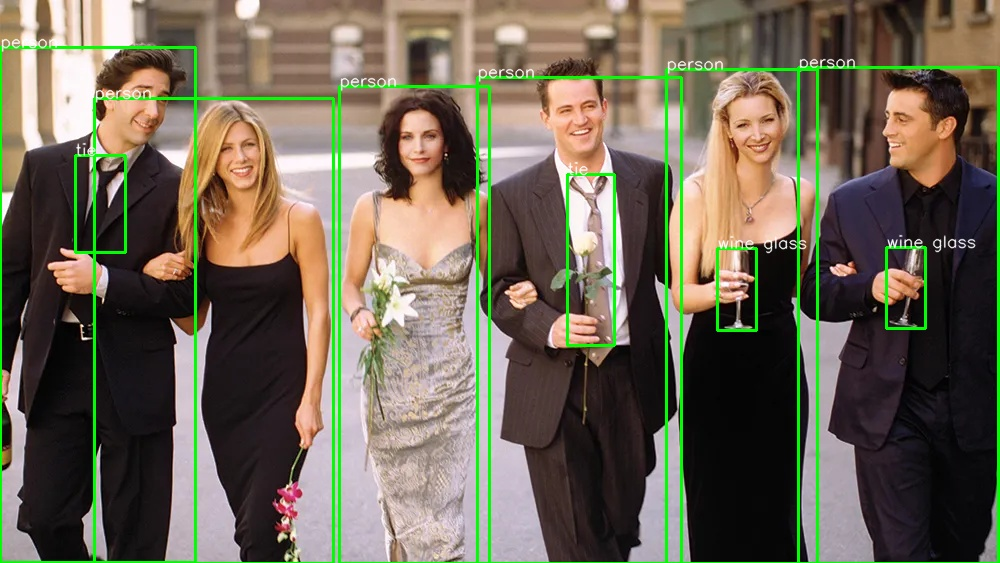

In [13]:
from IPython.display import Image, display
ok, encoded = cv2.imencode(".jpg", image_out)
if ok:
    display(Image(data=encoded.tobytes()))
else:
    print("Could not encode annotated image")


## What To Remember

Neat can perform YOLO box decode and return a compact BBOX tensor.

The Python CPU step here is not neural-network inference; it parses the decoded binary payload and turns each record into display logic.

The first 4 bytes are the detection count. Every detection record after that is `x, y, w, h, confidence, class_id`.

CPU parsing is useful when you want custom application logic after Neat BoxDecode, such as class-wise filtering, per-class thresholds, custom NMS, or drawing rules.


## References

- Public tutorial: [read detection boxes](https://developer.sima.ai/software/tutorials/read-detection-boxes).
- Core source: [read_detection_boxes.py](https://github.com/sima-neat/core/blob/main/tutorials/007_read_detection_boxes/read_detection_boxes.py).
- Model/package examples: [core/tutorials](https://github.com/sima-neat/core/tree/main/tutorials).
- COCO labels follow the standard 80-class object detection order used by YOLO COCO models.